# IPL Data Acquisition & Exploratory Data Analysis

This notebook performs exploratory data analysis (EDA) on IPL ball-by-ball
and match-level datasets to understand patterns in runs, wickets, venues,
and team performance.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")


In [3]:
deliveries = pd.read_csv("data/deliveries.csv")
matches = pd.read_csv("data/matches.csv")

print(deliveries.head())
print(matches.head())


   match_id  inning           batting_team                 bowling_team  over  \
0    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
1    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
2    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
3    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
4    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   

   ball       batter   bowler  non_striker  batsman_runs  extra_runs  \
0     1   SC Ganguly  P Kumar  BB McCullum             0           1   
1     2  BB McCullum  P Kumar   SC Ganguly             0           0   
2     3  BB McCullum  P Kumar   SC Ganguly             0           1   
3     4  BB McCullum  P Kumar   SC Ganguly             0           0   
4     5  BB McCullum  P Kumar   SC Ganguly             0           0   

   total_runs extras_type  is_wicket player_dismissed dismissal_kind fielder  
0

In [4]:
print("Deliveries Info:")
print(deliveries.info())

print("\nMatches Info:")
print(matches.info())


Deliveries Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           935

In [5]:
# Rename id -> match_id
matches = matches.rename(columns={"id": "match_id"})

# Select relevant columns
deliveries = deliveries[
    ["match_id", "inning", "batter", "bowler", "batsman_runs", "is_wicket"]
]

matches = matches[
    ["match_id", "season", "venue", "team1", "team2", "winner"]
]

deliveries.head(), matches.head()


(   match_id  inning       batter   bowler  batsman_runs  is_wicket
 0    335982       1   SC Ganguly  P Kumar             0          0
 1    335982       1  BB McCullum  P Kumar             0          0
 2    335982       1  BB McCullum  P Kumar             0          0
 3    335982       1  BB McCullum  P Kumar             0          0
 4    335982       1  BB McCullum  P Kumar             0          0,
    match_id   season                                       venue  \
 0    335982  2007/08                       M Chinnaswamy Stadium   
 1    335983  2007/08  Punjab Cricket Association Stadium, Mohali   
 2    335984  2007/08                            Feroz Shah Kotla   
 3    335985  2007/08                            Wankhede Stadium   
 4    335986  2007/08                                Eden Gardens   
 
                          team1                        team2  \
 0  Royal Challengers Bangalore        Kolkata Knight Riders   
 1              Kings XI Punjab          Chenna

In [6]:
print("Missing values in deliveries:")
print(deliveries.isnull().sum())

print("\nMissing values in matches:")
print(matches.isnull().sum())


Missing values in deliveries:
match_id        0
inning          0
batter          0
bowler          0
batsman_runs    0
is_wicket       0
dtype: int64

Missing values in matches:
match_id    0
season      0
venue       0
team1       0
team2       0
winner      5
dtype: int64


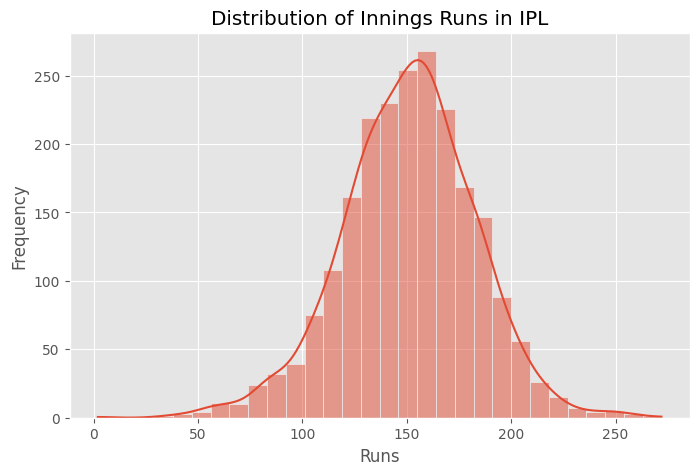

In [7]:
innings_runs = deliveries.groupby(
    ["match_id", "inning"]
)["batsman_runs"].sum().reset_index()

innings_runs = innings_runs[innings_runs["inning"] <= 2]

plt.figure(figsize=(8,5))
sns.histplot(innings_runs["batsman_runs"], bins=30, kde=True)
plt.title("Distribution of Innings Runs in IPL")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.show()


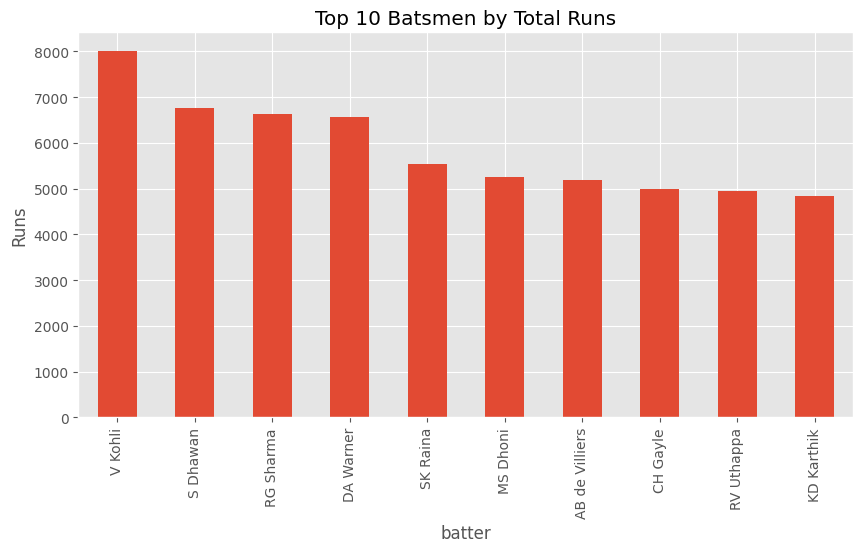

In [8]:
top_batsmen = (
    deliveries.groupby("batter")["batsman_runs"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_batsmen.plot(kind="bar")
plt.title("Top 10 Batsmen by Total Runs")
plt.ylabel("Runs")
plt.show()


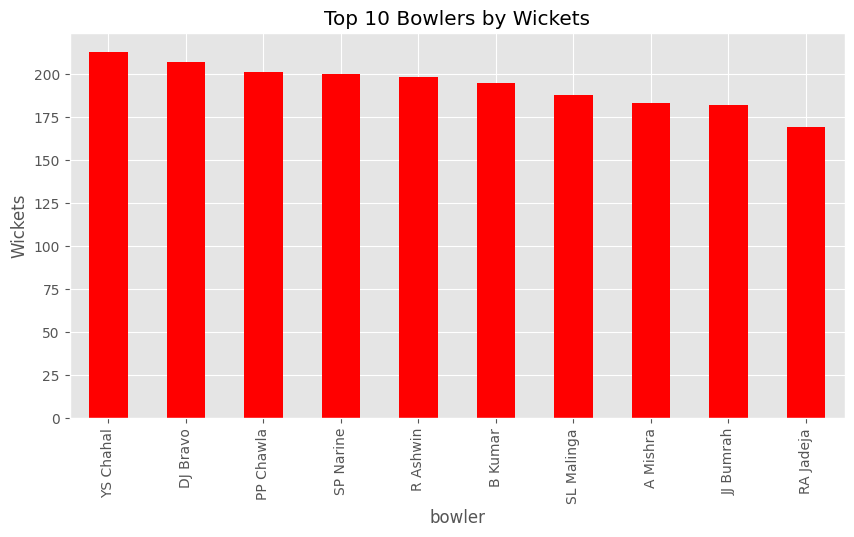

In [9]:
wickets = deliveries[deliveries["is_wicket"] == 1]

top_bowlers = (
    wickets.groupby("bowler")["is_wicket"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_bowlers.plot(kind="bar", color="red")
plt.title("Top 10 Bowlers by Wickets")
plt.ylabel("Wickets")
plt.show()


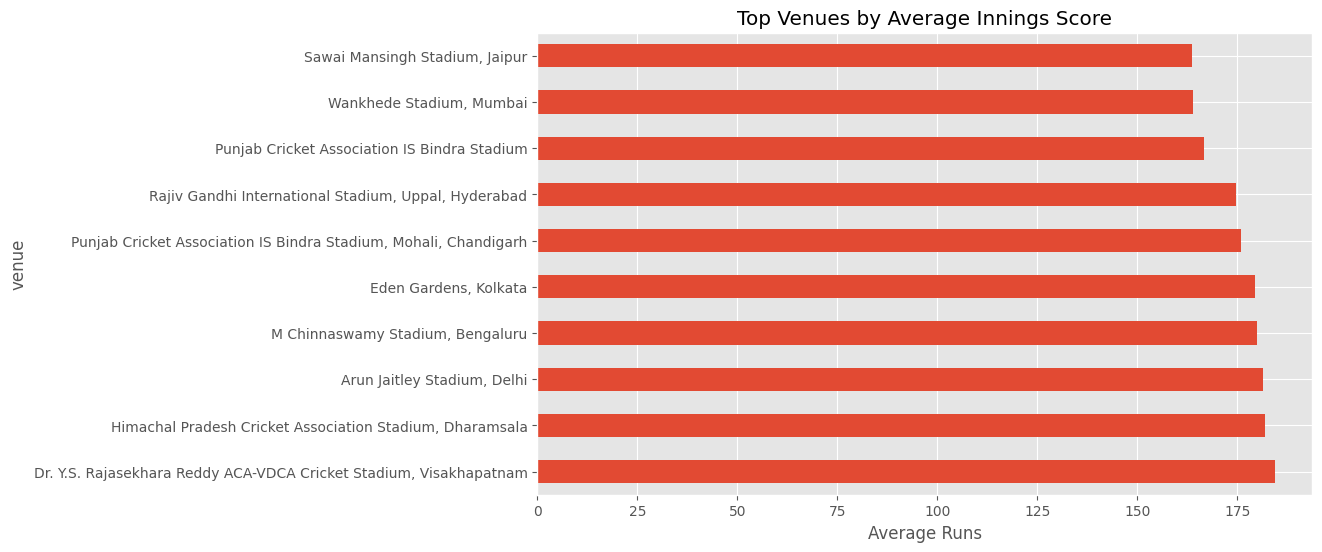

In [10]:
venue_scores = innings_runs.merge(
    matches[["match_id", "venue"]],
    on="match_id",
    how="left"
)

venue_avg = (
    venue_scores.groupby("venue")["batsman_runs"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
venue_avg.plot(kind="barh")
plt.title("Top Venues by Average Innings Score")
plt.xlabel("Average Runs")
plt.show()


## Key Findings

- Most IPL innings scores lie between 140 and 180 runs.
- A small group of batsmen contribute significantly to total IPL runs.
- Certain venues consistently produce higher-scoring matches.
- Wickets are concentrated among a few top-performing bowlers.
